# [TEMP] 2. Batching, Load, and the Throughput–Latency Trade-off

Lecture 1 showed that a lone decode step is **memory-bound**: the GPU streams
13 GB of weights to produce one token. Most of its compute sits idle. The fix
that every serving system uses is to **batch** requests. One pass over the
weights then produces one token for *each* request in the batch.

That raises two questions for a serving system:

1. How much throughput does batching buy, and what does it cost in latency?
2. With requests arriving at random times, what load can one GPU sustain before
   latency blows up?

:::{admonition} Learning goals
- Quantify how batch size trades per-token latency for throughput.
- Read a throughput–latency curve and find its "knee".
- Explain why tail latency (p99) degrades long before median latency does.
:::

## Setup

In [1]:
import os, sys, urllib.request
sys.path.insert(0, os.path.abspath("../../labs"))
try:
    import llm_systems_wo_gpus as lsg
except ImportError:
    urllib.request.urlretrieve(
        "https://raw.githubusercontent.com/kwmaeng91/studying-llm-systems-without-gpus/main/labs/llm_systems_wo_gpus.py",
        "llm_systems_wo_gpus.py")
    import llm_systems_wo_gpus as lsg
lsg.setup()

import matplotlib.pyplot as plt
import pandas as pd
plt.rcParams.update({"figure.figsize": (6, 3.5), "axes.grid": True, "grid.alpha": .3})

Simulator ready at /home/kiwan/.llm-systems-wo-gpus/backend


## Batching an offline workload

Start with the simplest case, an **offline** job: 256 requests (512 prompt
tokens, 128 output tokens each) all arrive at time 0 (`qps=None`). We cap how
many requests the scheduler may run together with `batch_size_cap`.
`batch_size_cap=1` is the "no batching" baseline.

In [2]:
caps = [1, 2, 4, 8, 16, 32, 64, 128]
offline = lsg.sweep("batch_size_cap", caps, qps=None, num_requests=256)
offline[["TPOT p50 (ms)", "throughput (tok/s)", "makespan (s)"]]

,TPOT p50 (ms),throughput (tok/s),makespan (s)
batch_size_cap,,,
1.0,9.449,513.620,318.991
2.0,9.842,979.115,167.335
4.0,10.689,1772.371,92.441
8.0,12.789,2981.147,54.959
16.0,16.045,4775.933,34.305
32.0,22.651,6773.347,24.189
64.0,35.708,8413.635,19.473
128.0,50.349,9034.373,18.135


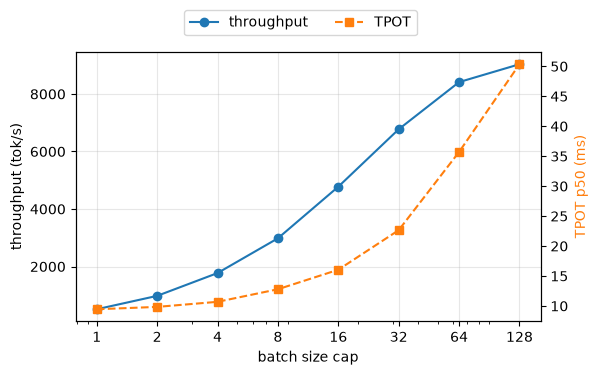

In [3]:
fig, ax1 = plt.subplots()
ax1.plot(caps, offline["throughput (tok/s)"], "o-", label="throughput")
ax1.set(xscale="log", xlabel="batch size cap", ylabel="throughput (tok/s)")
ax1.set_xticks(caps, caps)
ax2 = ax1.twinx()
ax2.plot(caps, offline["TPOT p50 (ms)"], "s--", color="C1", label="TPOT")
ax2.set_ylabel("TPOT p50 (ms)", color="C1"); ax2.grid(False)
fig.legend(loc="upper center", ncol=2, bbox_to_anchor=(.5, 1.02));

Up to a batch of about 8, throughput grows **almost linearly** with batch size
while TPOT barely moves. The GPU was memory-bound, so the extra requests ride
along nearly for free. Beyond that, the work per step (the matrix multiplies and
especially attention over every request's KV cache) becomes significant, and
returns diminish: going from 32 to 128 buys only ~1.3× more throughput but more
than doubles TPOT. **The right batch size depends on how much latency you can afford.**

:::{note}
Batch size is not only a scheduler setting. Every running request keeps its
KV cache in GPU memory, so the largest *possible* batch is limited by
`(GPU memory − weights) / (KV bytes per token × tokens per request)`. In Llama-2-7B
a token's KV cache takes $2 \times 32\ \text{layers} \times 4096 \times 2\ \text{B} = 512$ KB.
:::

## Online serving: requests arrive over time

Real services see requests arriving at random. We model arrivals as a
**Poisson process** with rate `qps` and sweep the load. Every other setting stays
at its default (`batch_size_cap=128`).

In [4]:
loads = [1, 2, 4, 8, 12, 14, 16, 20, 24, 32]
online = lsg.sweep("qps", loads, num_requests=300)
online[["TTFT p50 (ms)", "TTFT p99 (ms)", "TPOT p50 (ms)", "queueing p50 (ms)", "throughput (tok/s)"]]

,TTFT p50 (ms),TTFT p99 (ms),TPOT p50 (ms),queueing p50 (ms),throughput (tok/s)
qps,,,,,
1.0,51.178,82.442,9.960,3.162,699.282
2.0,54.067,92.746,10.668,4.933,1392.006
4.0,59.056,136.701,12.824,7.307,2757.385
8.0,83.982,216.373,19.066,10.018,5384.281
12.0,119.534,357.392,32.853,29.772,7708.522
14.0,194.771,823.486,47.953,88.048,8557.466
16.0,992.644,2454.953,50.419,853.532,8795.077
20.0,2391.344,5364.992,51.068,2257.380,8946.687
24.0,3291.582,7304.712,51.325,3180.224,9037.267


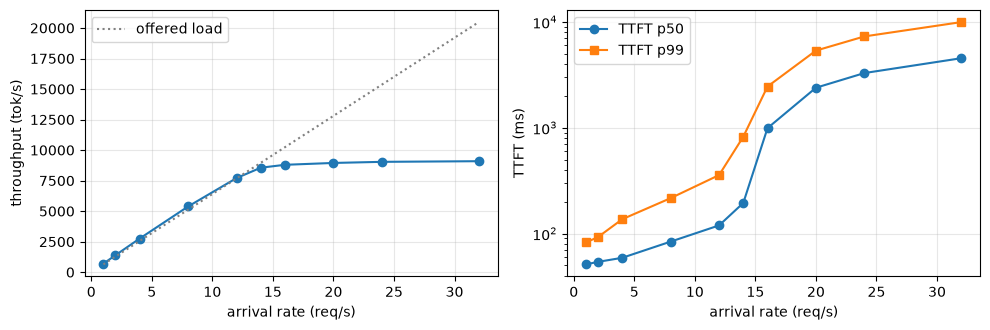

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].plot(online.index, online["throughput (tok/s)"], "o-")
ax[0].plot(online.index, online.index * (512 + 128), ":", color="gray", label="offered load")
ax[0].set(xlabel="arrival rate (req/s)", ylabel="throughput (tok/s)"); ax[0].legend()
ax[1].plot(online.index, online["TTFT p50 (ms)"], "o-", label="TTFT p50")
ax[1].plot(online.index, online["TTFT p99 (ms)"], "s-", label="TTFT p99")
ax[1].set(xlabel="arrival rate (req/s)", ylabel="TTFT (ms)", yscale="log"); ax[1].legend()
fig.tight_layout()

There are two regimes:

- **Below the knee** (≲ 12 req/s), throughput tracks the offered load: every
  request is served as it arrives. Latency still creeps up, because more
  concurrent requests mean larger batches and slower steps.
- **Past the knee**, throughput flattens at the GPU's capacity (~9k tok/s,
  close to the offline maximum above) and the extra requests **queue**. TTFT jumps
  by an order of magnitude and would keep growing without bound if the
  experiment ran longer.

Also notice that **p99 TTFT degrades well before p50**. Poisson arrivals come in
bursts, and the unlucky requests that land in a burst wait behind it. A service
with a latency target ("p99 TTFT < 500 ms") therefore has to run well below
its raw capacity.

## Goodput: throughput that meets the SLO

A common way to collapse this curve into a single number is **goodput**: the
highest load at which a latency target (SLO) still holds.

In [6]:
slo_ttft_ms, slo_tpot_ms = 500, 25
ok = online[(online["TTFT p99 (ms)"] < slo_ttft_ms) & (online["TPOT p99 (ms)"] < slo_tpot_ms)]
print(f"Max load meeting p99 TTFT<{slo_ttft_ms}ms and p99 TPOT<{slo_tpot_ms}ms: "
      f"{ok.index.max()} req/s  ->  {ok['throughput (tok/s)'].max():.0f} tok/s goodput")

Max load meeting p99 TTFT<500ms and p99 TPOT<25ms: 8.0 req/s  ->  5384 tok/s goodput


## Exercises

:::{admonition} Try it
:class: exercise
1. Rerun the online sweep with `batch_size_cap=16`. How do the knee and the
   saturation throughput move? Is there any load at which the smaller cap is
   *better*?
2. Make the workload decode-heavy (`prefill_tokens=128, decode_tokens=512`) and then
   prefill-heavy (`prefill_tokens=2048, decode_tokens=32`). Which saturates at a
   higher **request** rate, and which at a higher **token** rate? Why?
3. Tighten the SLO to p99 TTFT < 200 ms. How much goodput do you lose? Then
   try 2 replicas (`num_replicas=2`) at twice the load. Does goodput double?
:::